In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import nltk
from sklearn.metrics import confusion_matrix
import seaborn as sns

nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to C:\Users\KARUN
[nltk_data]     NAGARAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\KARUN
[nltk_data]     NAGARAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
df = pd.read_csv("C:\\Users\\KARUN NAGARAJ\\Downloads\\restaurant_reviews_100.csv")
print(df.head())

                                              Review
0  The food was absolutely delicious and the serv...
1  Very bad experience, the food was cold and tas...
2  Amazing ambiance and friendly staff, loved the...
3          Service was slow and the waiter was rude.
4      The pizza was fantastic, fresh and flavorful.


In [7]:
from nltk.corpus import stopwords
import re

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = [word for word in text.split() if word not in stop_words]
    
    return ' '.join(words)

df['Cleaned_Reviews'] = df['Review'].apply(preprocess_text)

print(df.head())

                                              Review  \
0  The food was absolutely delicious and the serv...   
1  Very bad experience, the food was cold and tas...   
2  Amazing ambiance and friendly staff, loved the...   
3          Service was slow and the waiter was rude.   
4      The pizza was fantastic, fresh and flavorful.   

                                    Cleaned_Reviews  
0      food absolutely delicious service excellent.  
1              bad experience, food cold tasteless.  
2  amazing ambiance friendly staff, loved desserts.  
3                         service slow waiter rude.  
4                 pizza fantastic, fresh flavorful.  


In [8]:
#sentiment analysis (NLTK VADER)
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
    
df['Sentiment'] = df['Cleaned_Reviews'].apply(analyze_sentiment)
print(df.head())
   

                                              Review  \
0  The food was absolutely delicious and the serv...   
1  Very bad experience, the food was cold and tas...   
2  Amazing ambiance and friendly staff, loved the...   
3          Service was slow and the waiter was rude.   
4      The pizza was fantastic, fresh and flavorful.   

                                    Cleaned_Reviews Sentiment  
0      food absolutely delicious service excellent.  Positive  
1              bad experience, food cold tasteless.  Negative  
2  amazing ambiance friendly staff, loved desserts.  Positive  
3                         service slow waiter rude.  Negative  
4                 pizza fantastic, fresh flavorful.  Positive  


In [9]:
print('sentiment distribution:')
print(df['Sentiment'].value_counts())

sentiment distribution:
Sentiment
Positive    42
Neutral     37
Negative    21
Name: count, dtype: int64


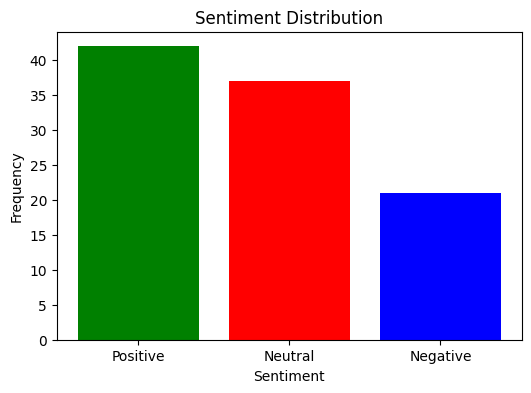

In [10]:
#bar plot of frequency of each sentiment category
plt.figure(figsize=(6,4))
plt.bar(df['Sentiment'].value_counts().index, df['Sentiment'].value_counts().values, color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

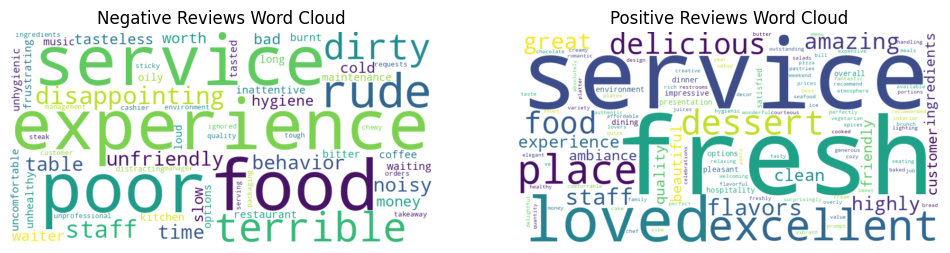

In [11]:
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Cleaned_Reviews'])
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Cleaned_Reviews'])

negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')
plt.show()

In [12]:
#Text similarity using TF-IDF and cosine similarity

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Cleaned_Reviews'])
print("TF-IDF Matrix ", tfidf_matrix)

TF-IDF Matrix  <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 384 stored elements and shape (100, 254)>
  Coords	Values
  (0, 87)	0.3622979304891482
  (0, 0)	0.5542728961732952
  (0, 57)	0.4762162573021909
  (0, 199)	0.3622979304891482
  (0, 76)	0.45108763225710546
  (1, 87)	0.34133760764465015
  (1, 14)	0.5222060863185941
  (1, 79)	0.3892918256824126
  (1, 39)	0.47918749747676936
  (1, 220)	0.47918749747676936
  (2, 3)	0.40315584209232186
  (2, 4)	0.43058206012619554
  (2, 92)	0.43058206012619554
  (2, 209)	0.33707454080863397
  (2, 125)	0.36450075884250766
  (2, 62)	0.46923714337600975
  (3, 199)	0.3803518359052308
  (3, 202)	0.533957701484403
  (3, 243)	0.533957701484403
  (3, 186)	0.533957701484403
  (4, 156)	0.5098060605861892
  (4, 82)	0.5555734009798956
  (4, 89)	0.41416634013740644
  (4, 85)	0.5098060605861892
  (5, 223)	0.4780797056740709
  :	:
  (92, 107)	0.5620612117942797
  (93, 61)	0.5192179878036876
  (93, 148)	0.6043230432231961
  (93, 214)	0.6043230432231

In [13]:
similarity_matrix = cosine_similarity(tfidf_matrix)
print("cosine similarity matrix between two reviews ", similarity_matrix[0, 1])

cosine similarity matrix between two reviews  0.12366590884777365


In [14]:
print("Full cosine similarity matrix: ", similarity_matrix)

Full cosine similarity matrix:  [[1.         0.12366591 0.         ... 0.         0.13310418 0.14791676]
 [0.12366591 1.         0.         ... 0.         0.12540359 0.18126668]
 [0.         0.         1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.13310418 0.12540359 0.         ... 0.         1.         0.        ]
 [0.14791676 0.18126668 0.         ... 0.         0.         1.        ]]


In [15]:
#TEXT CLASSIFICATION USING NAIVE BAYES
X_train, X_test, y_train, y_test = train_test_split(df['Cleaned_Reviews'], df['Sentiment'], test_size=0.1, random_state=42)

cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

model = MultinomialNB()
model.fit(X_train_cv, y_train)

y_pred = model.predict(X_test_cv)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
     Neutral       0.67      0.50      0.57         4
    Positive       0.60      0.75      0.67         4

    accuracy                           0.60        10
   macro avg       0.59      0.58      0.58        10
weighted avg       0.61      0.60      0.60        10

Accuracy:  0.6


Confusion Matrix:
 [[3 0 1]
 [1 1 0]
 [1 1 2]]


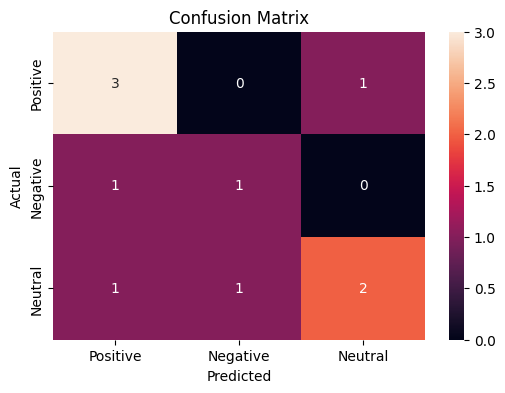

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Negative', 'Neutral'])
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Positive', 'Negative', 'Neutral'], yticklabels=['Positive', 'Negative', 'Neutral'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()  

In [ ]:
text = "Hey there! 😃 I can't believe it's already 2024. Did you see John's new blog post? Check it out at https://example.com/blog! Also, email me at john.doe@example.com. He mentioned something " \
"about stemming and lemmatization—interesting stuff. BTW, I'll be attending the AI conference in N.Y.C. next month!! #Excited #AI 😊 Let's catch up soon. Cheers, John"

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    #tokenization
    tokens = text.split()
    text = ' '.join(tokens)
    
    return text

text = preprocess_text(text)
print("Preprocessed Text: ", text)

TypeError: count() takes at least 1 argument (0 given)